# Predicting Arrest Outcomes During Terry Stops Using Classification Models

---

## Section 1: Business Understanding

### Stakeholder
The **Seattle City Council's Public Safety Committee** is tasked with reviewing police conduct, evaluating racial equity in policing, and recommending policy reforms.

### Business Problem
Terry Stops allow officers to temporarily detain individuals based on "reasonable suspicion" — a lower bar than the probable cause required for a full arrest.

The critical question for policymakers is: **what factors actually predict whether a Terry Stop leads to an arrest?**

And importantly: **does the race of the subject or officer play a statistically meaningful role?**

If race is predictive above and beyond legitimate law-enforcement factors (e.g., weapon presence, call type), that would indicate a systemic bias requiring corrective policy action.

## Why classification?
We want to build a **machine learning model** that can predict:

> **Will this Terry Stop result in an arrest? (Yes or No)**

This is called a **binary classification** problem because there are only two possible answers.

### Classification Goal
To build a binary classifier that predicts `Arrest Flag` (Y/N) from available stop features, enabling the committee to:
1. Identify the strongest predictors of arrest
2. Audit for racial disparities
3. Prioritize oversight resources

---

## Section 2: Data Understanding

### 2.0 Import all the necessary libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

### 2.1 Loading The Dataset

In [2]:
df = pd.read_csv('Terry_Stops_20260505.csv')
df.head()

,Subject Age Group,Subject ID,GO / SC Num,Terry Stop ID,Stop Resolution,Weapon Type,Officer ID,Officer YOB,Officer Gender,Officer Race,...,Initial Call Type,Final Call Type,Call Type,Officer Squad,Arrest Flag,Frisk Flag,Precinct,Sector,Beat,Occurred Date
0,56 and Above,-1,20190000057245,532414,Arrest,NaN,8606,1965,Female,White,...,ASLT - WITH OR W/O WPNS (NO SHOOTINGS),"ASSAULTS, OTHER",911,TRAINING - FIELD TRAINING SQUAD,N,N,West,M,M3,2019-02-15T13:15:00
1,46 - 55,7729078044,20230000235837,51923259552,Field Contact,-,4494,1961,Male,White,...,DISTURBANCE,MISCHIEF OR NUISANCE - GENERAL,911,CRG - SQUAD 81D,N,Y,Southwest,W,W1,2023-08-16T20:31:00
2,36 - 45,7727706299,20250000063255,63109655222,Field Contact,-,8974,1997,Female,White,...,SUSPICIOUS STOP - OFFICER INITIATED ONVIEW,SUSPICIOUS CIRCUM. - SUSPICIOUS PERSON,ONVIEW,NORTH PCT 2ND W - BOY (JOHN) - PLATOON 1,N,N,North,U,U2,2025-03-08T17:58:00
3,26 - 35,-1,20180000002293,434590,Field Contact,NaN,8022,1990,Male,Hispanic,...,-,-,-,TRAINING - FIELD TRAINING SQUAD,N,N,-,-,-,2018-06-24T18:49:00
4,-,31629429379,20220000039527,31629401025,Field Contact,Knife/Cutting/Stabbing Instrument,6885,1976,Male,Asian,...,DISTURBANCE,SUSPICIOUS CIRCUM. - SUSPICIOUS PERSON,ONVIEW,WEST PCT 2ND W - SPECIAL BEATS,N,Y,West,M,M2,2022-02-15T17:42:00


### 2.2 Data Inspection

In [3]:
# Dataset shape - returns the number of rows and columns in the dataset
df.shape

(67362, 23)

In [4]:
# Dataset Info - provides information about the dataset, including the column names, number of non-null values, data types of each column and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67362 entries, 0 to 67361
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Subject Age Group         67362 non-null  object
 1   Subject ID                67362 non-null  int64 
 2   GO / SC Num               67362 non-null  int64 
 3   Terry Stop ID             67362 non-null  int64 
 4   Stop Resolution           67362 non-null  object
 5   Weapon Type               34797 non-null  object
 6   Officer ID                67362 non-null  object
 7   Officer YOB               67362 non-null  int64 
 8   Officer Gender            67362 non-null  object
 9   Officer Race              67362 non-null  object
 10  Subject Perceived Race    67362 non-null  object
 11  Subject Perceived Gender  67362 non-null  object
 12  Reported Date             67362 non-null  object
 13  Initial Call Type         67362 non-null  object
 14  Final Call Type       

In [5]:
# Statistical Summary - provides a statistical summary of the dataset, including count, mean, standard deviation, minimum, 25th percentile, median, 75th percentile and maximum values for each numerical column
# For categorical columns, it provides the count, unique values, top value and frequency of the top value
df.describe(include='all')

,Subject Age Group,Subject ID,GO / SC Num,Terry Stop ID,Stop Resolution,Weapon Type,Officer ID,Officer YOB,Officer Gender,Officer Race,...,Initial Call Type,Final Call Type,Call Type,Officer Squad,Arrest Flag,Frisk Flag,Precinct,Sector,Beat,Occurred Date
count,67362,6.736200e+04,6.736200e+04,6.736200e+04,67362,34797,67362,67362.000000,67362,67362,...,67362,67362,67362,66790,67362,67362,67362,67362,67362,67362
unique,7,NaN,NaN,NaN,5,22,1500,NaN,3,9,...,186,205,9,282,2,3,9,20,55,62615
top,26 - 35,NaN,NaN,NaN,Field Contact,-,7456,NaN,Male,White,...,-,-,911,TRAINING - FIELD TRAINING SQUAD,N,N,West,-,-,2024-11-11T02:39:00
freq,22385,NaN,NaN,NaN,34160,30445,552,NaN,59649,47470,...,13672,13672,31730,7633,59542,50344,19487,11104,11098,15
mean,NaN,1.033325e+10,2.019261e+13,1.713958e+10,NaN,NaN,NaN,1984.706244,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,1.728265e+10,8.368889e+10,2.273201e+10,NaN,NaN,NaN,9.294822,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,-8.000000e+00,-1.000000e+00,2.802000e+04,NaN,NaN,NaN,1900.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,-1.000000e+00,2.017000e+13,2.654072e+05,NaN,NaN,NaN,1980.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,-1.000000e+00,2.019000e+13,5.509790e+05,NaN,NaN,NaN,1986.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,8.336892e+09,2.022000e+13,3.196693e+10,NaN,NaN,NaN,1991.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.3 Data Cleaning

In [6]:
# Check for Missing Values - returns the number of missing values in each column of the dataset
df.isnull().sum()

Subject Age Group               0
Subject ID                      0
GO / SC Num                     0
Terry Stop ID                   0
Stop Resolution                 0
Weapon Type                 32565
Officer ID                      0
Officer YOB                     0
Officer Gender                  0
Officer Race                    0
Subject Perceived Race          0
Subject Perceived Gender        0
Reported Date                   0
Initial Call Type               0
Final Call Type                 0
Call Type                       0
Officer Squad                 572
Arrest Flag                     0
Frisk Flag                      0
Precinct                        0
Sector                          0
Beat                            0
Occurred Date                   0
dtype: int64

In [7]:
# Check for placeholder values
(df == '-').sum().sort_values(ascending=False)

Weapon Type                 30445
Call Type                   13672
Final Call Type             13672
Initial Call Type           13672
Sector                      11104
Beat                        11098
Precinct                    10953
Subject Age Group            2480
Subject Perceived Race       1819
Frisk Flag                    478
Subject Perceived Gender      242
Officer ID                     24
Subject ID                      0
Reported Date                   0
Officer Race                    0
Officer Gender                  0
Officer YOB                     0
Officer Squad                   0
Arrest Flag                     0
Stop Resolution                 0
Terry Stop ID                   0
GO / SC Num                     0
Occurred Date                   0
dtype: int64

In [8]:
# Replace placeholder values with NaN
df.replace('-', np.nan, inplace=True)

In [9]:
(df == '-').sum().sort_values(ascending=False)

Subject Age Group           0
Reported Date               0
Beat                        0
Sector                      0
Precinct                    0
Frisk Flag                  0
Arrest Flag                 0
Officer Squad               0
Call Type                   0
Final Call Type             0
Initial Call Type           0
Subject Perceived Gender    0
Subject ID                  0
Subject Perceived Race      0
Officer Race                0
Officer Gender              0
Officer YOB                 0
Officer ID                  0
Weapon Type                 0
Stop Resolution             0
Terry Stop ID               0
GO / SC Num                 0
Occurred Date               0
dtype: int64

In [10]:
df.isnull().sum()

Subject Age Group            2480
Subject ID                      0
GO / SC Num                     0
Terry Stop ID                   0
Stop Resolution                 0
Weapon Type                 63010
Officer ID                     24
Officer YOB                     0
Officer Gender                  0
Officer Race                    0
Subject Perceived Race       1819
Subject Perceived Gender      242
Reported Date                   0
Initial Call Type           13672
Final Call Type             13672
Call Type                   13672
Officer Squad                 572
Arrest Flag                     0
Frisk Flag                    478
Precinct                    10953
Sector                      11104
Beat                        11098
Occurred Date                   0
dtype: int64

### Handling Missing Values
Since most of the affected columns are categorical variables, missing values were filled using 'Unknown' instead of removing rows or dropping columns.

Columns such as Weapon Type, Call Type, Precinct, and Beat may still contain useful predictive information even when some values are missing.

This approach helps:

1. Preserve important information
2. Avoid unnecessary data loss
3. Maintain consistency across categorical features.


In [11]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')

In [12]:
df.isnull().sum()

Subject Age Group           0
Subject ID                  0
GO / SC Num                 0
Terry Stop ID               0
Stop Resolution             0
Weapon Type                 0
Officer ID                  0
Officer YOB                 0
Officer Gender              0
Officer Race                0
Subject Perceived Race      0
Subject Perceived Gender    0
Reported Date               0
Initial Call Type           0
Final Call Type             0
Call Type                   0
Officer Squad               0
Arrest Flag                 0
Frisk Flag                  0
Precinct                    0
Sector                      0
Beat                        0
Occurred Date               0
dtype: int64

---

## Section 3: Exploratory Data Analysis (EDA)

### 3.0 Target Variable Analysis

This section explores our target variable **Arrest Flag** which indicates whether a Terry Stop resulted in an arrest.

In [13]:
# Analyze arrest outcomes
arrest_counts = df['Arrest Flag'].value_counts()
arrest_counts

Arrest Flag
N    59542
Y     7820
Name: count, dtype: int64

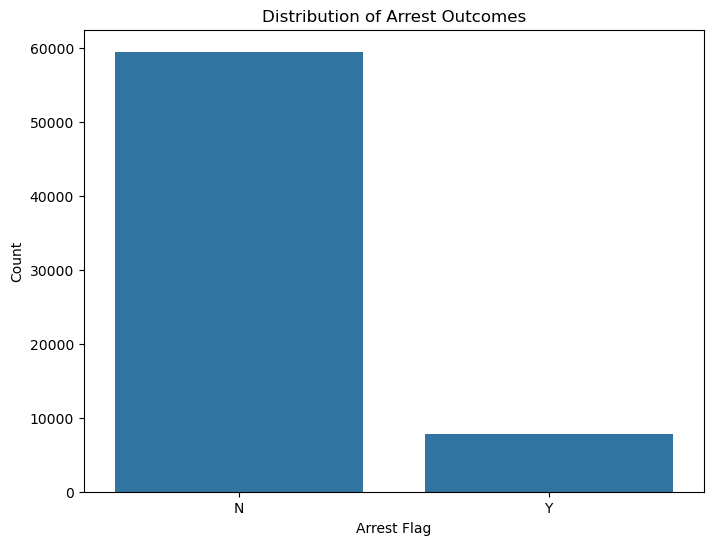

In [14]:
# Visualize arrest outcomes
plt.figure(figsize=(8, 6))
sns.countplot(x='Arrest Flag', data=df)
plt.title('Distribution of Arrest Outcomes')
plt.xlabel('Arrest Flag')
plt.ylabel('Count')
plt.show()

The dataset is heavily dominated by Terry Stops that did not result in arrests. Out of all recorded stops, **59,542** incidents resulted in no arrest (N), while only **7,820** resulted in an arrest (Y).

This shows a clear **class imbalance** within the target variable, where non-arrest outcomes (about 88% of stops) occur much more frequently than arrest outcomes.

---
### 3.1 Subject Demographics Analysis

This section explores demographic characteristics of subjects involved in Terry Stops, including perceived race, gender, and age group distributions.

### Subject Percieved Race

In [15]:
# Analyze race demographics
race_counts = df['Subject Perceived Race'].value_counts()
race_counts

Subject Perceived Race
White                                        32859
Black or African American                    20401
Unknown                                       7130
Asian                                         2333
American Indian or Alaska Native              1790
Hispanic                                      1684
Multi-Racial                                   809
Native Hawaiian or Other Pacific Islander      203
Other                                          152
MULTIPLE SUBJECTS                                1
Name: count, dtype: int64

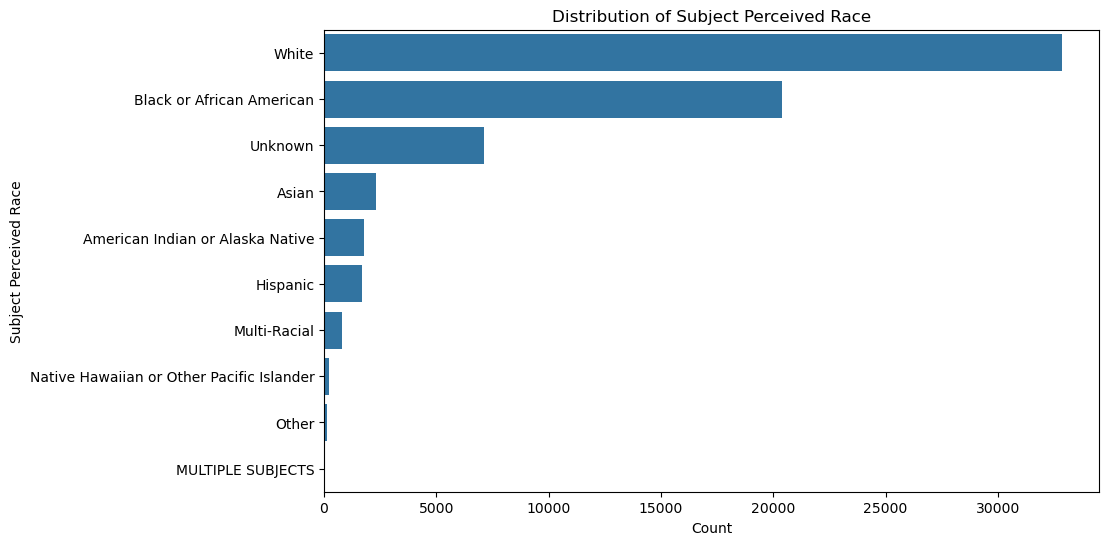

In [16]:
# Visualize race demographics
plt.figure(figsize=(10,6))

sns.countplot(
    y='Subject Perceived Race',
    data=df,
    order=df['Subject Perceived Race'].value_counts().index
)

plt.title('Distribution of Subject Perceived Race')
plt.xlabel('Count')
plt.ylabel('Subject Perceived Race')

plt.show()

The distribution of Subject Perceived Race shows that Terry Stops are not evenly distributed across racial groups in the dataset.

The largest group of individuals involved in stops are **White (32,859) subjects**, followed by **Black or African American (20,401) subjects**. These two categories make up the majority of recorded cases, indicating that Terry Stops are most frequently associated with these two groups compared to others.

A significant portion of records fall under **Unknown (7,130)**, which suggests missing or unrecorded racial information. This could be due to incomplete reporting or situations where officers did not assign a perceived race.

Other racial groups appear in much smaller proportions. These include **Asian (2,333)**, **American Indian or Alaska Native (1,790)**, and **Hispanic (1,684)** individuals. Additionally, **Multi-Racial (809)**, **Native Hawaiian or Other Pacific Islander (203)**, and **Other (152)** categories are minimally represented in the dataset. The **“MULTIPLE SUBJECTS” (1)** entry appears to be an outlier or data entry anomaly.

Overall, the distribution indicates a **strong imbalance** across racial categories, with a concentration in a few dominant groups and very low representation in others.

---
### Subject Perceived Gender

In [17]:
# Analyze gender demographics
gender_counts = df['Subject Perceived Gender'].value_counts()
gender_counts


Subject Perceived Gender
Male                                                         53119
Female                                                       13449
Unknown                                                        383
Unable to Determine                                            326
Gender Diverse (gender non-conforming and/or transgender)       84
MULTIPLE SUBJECTS                                                1
Name: count, dtype: int64

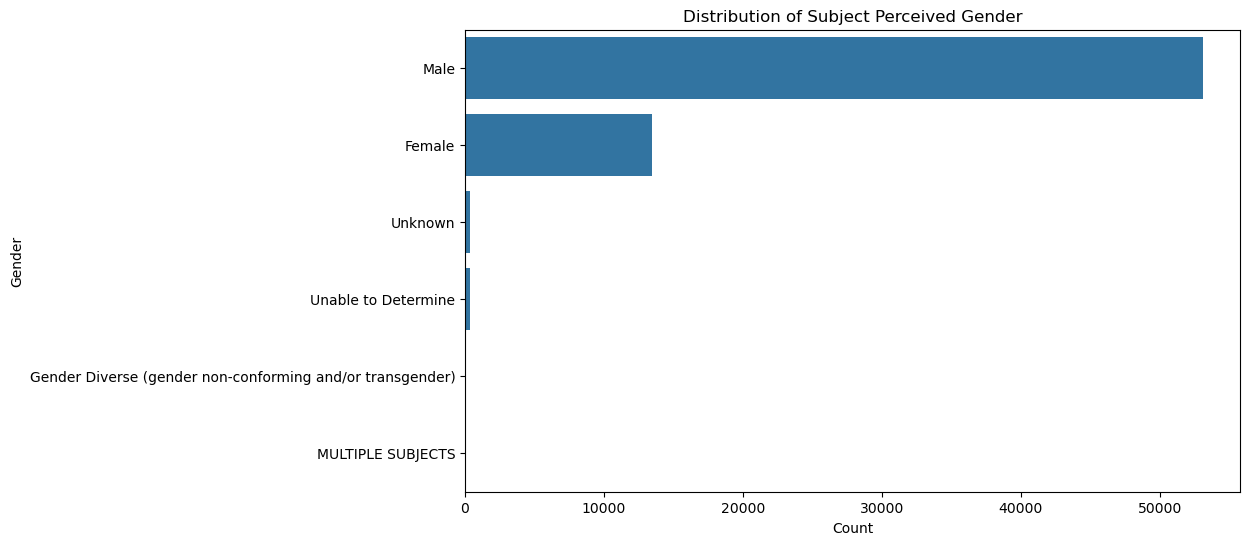

In [18]:
# Visualize gender demographics
plt.figure(figsize=(10, 6))

sns.countplot(
    y='Subject Perceived Gender',
    data=df,
    order=df['Subject Perceived Gender'].value_counts().index
)

plt.title('Distribution of Subject Perceived Gender')
plt.xlabel('Count')
plt.ylabel('Gender')

plt.show()

The distribution of Subject Perceived Gender shows that Terry Stops are heavily skewed toward male subjects in the dataset.

The majority of individuals involved in stops are **Male (53,119)**, making this the dominant category. This indicates that Terry Stops are significantly more likely to involve male subjects compared to other gender groups.

The second largest group is **Female (13,449)**, which is much lower in comparison but still represents a meaningful portion of the dataset.

A small number of records fall under uncertainty or missing classifications, including **Unknown (383)** and **Unable to Determine (326)**. These may reflect incomplete data collection or cases where gender could not be clearly identified.

The dataset also includes **Gender Diverse (gender non-conforming and/or transgender) individuals (84)**, which, while very small in number, is still important for ensuring inclusivity in the analysis.

Finally, **“MULTIPLE SUBJECTS” (1)** appears as an unusual entry and is likely a rare case or data recording anomaly.

Overall, the dataset shows a **clear gender imbalance**, with a strong dominance of male subjects in Terry Stops. Female and gender-diverse categories make up a much smaller proportion of the dataset.

---
### Subject Perceived Age

In [19]:
# Analyze age demographics
age_counts = df['Subject Age Group'].value_counts()
age_counts

Subject Age Group
26 - 35         22385
36 - 45         15493
18 - 25         12428
46 - 55          8513
56 and Above     3608
Unknown          2480
1 - 17           2455
Name: count, dtype: int64

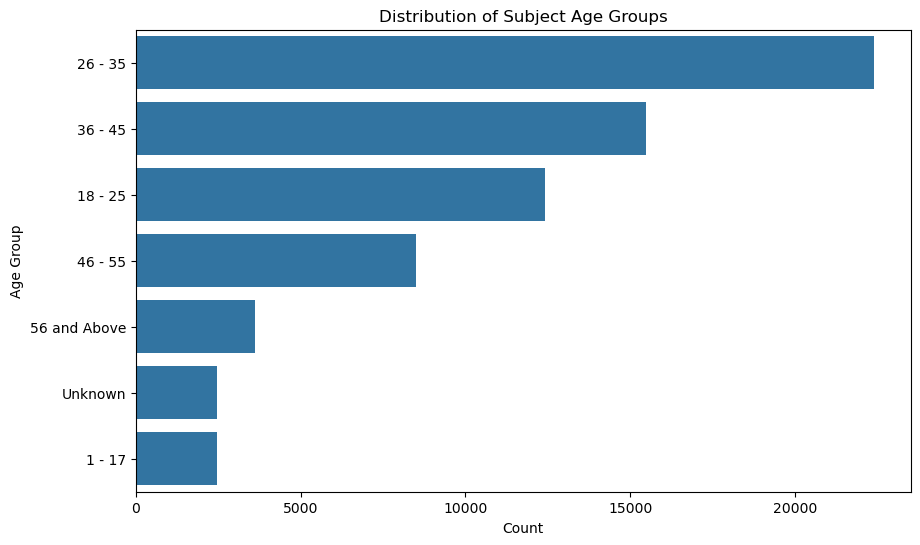

In [20]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='Subject Age Group',
    data=df,
    order=df['Subject Age Group'].value_counts().index
)

plt.title('Distribution of Subject Age Groups')
plt.xlabel('Count')
plt.ylabel('Age Group')

plt.show()

The distribution of Subject Age Group shows that Terry Stops are not evenly distributed across all age categories in the dataset.

The largest group involved in stops is the **26 - 35 age group (22,385)**, making it the most frequently represented category. This is followed by the **36 - 45 age group (15,493)** and the **18 - 25 age group (12,428)**. Together, these three groups make up the **majority of recorded stops**, indicating that Terry Stops are most commonly concentrated among young to middle-aged adults.

The **46 - 55 age group (8,513)** and **56 and Above (3,608)** categories appear less frequently, showing a **gradual decline** in representation as age increases.

A small number of records fall under **Unknown (2,480)**, which likely represents missing or unrecorded age information.

Interestingly, the dataset also includes **1 - 17 (2,455)**, indicating that a small number of minors are present in the records, although they represent a relatively small portion of total stops.

Overall, the distribution shows a **clear concentration of Terry Stops among working-age adults**, particularly those **between 18 and 45 years**. This suggests that younger and middle-aged individuals are most frequently involved in stop incidents, while older age groups are less represented.

The presence of unknown and under-18 categories highlights some data quality considerations, but overall the pattern is strongly centered on adult populations.

---
## 3.2 Stop Circumstances Analysis

This section examines the circumstances surrounding Terry Stops, including the type of call that initiated the stop, the presence of weapons, and whether a frisk was conducted.

### Call Type

In [21]:
# Analyze call type distribution
call_counts = df['Call Type'].value_counts()
call_counts

Call Type
911                              31730
ONVIEW                           16872
Unknown                          13672
TELEPHONE OTHER, NOT 911          4507
ALARM CALL (NOT POLICE ALARM)      545
TEXT MESSAGE                        33
HISTORY CALL (RETRO)                 1
SCHEDULED EVENT (RECURRING)          1
PROACTIVE (OFFICER INITIATED)        1
Name: count, dtype: int64

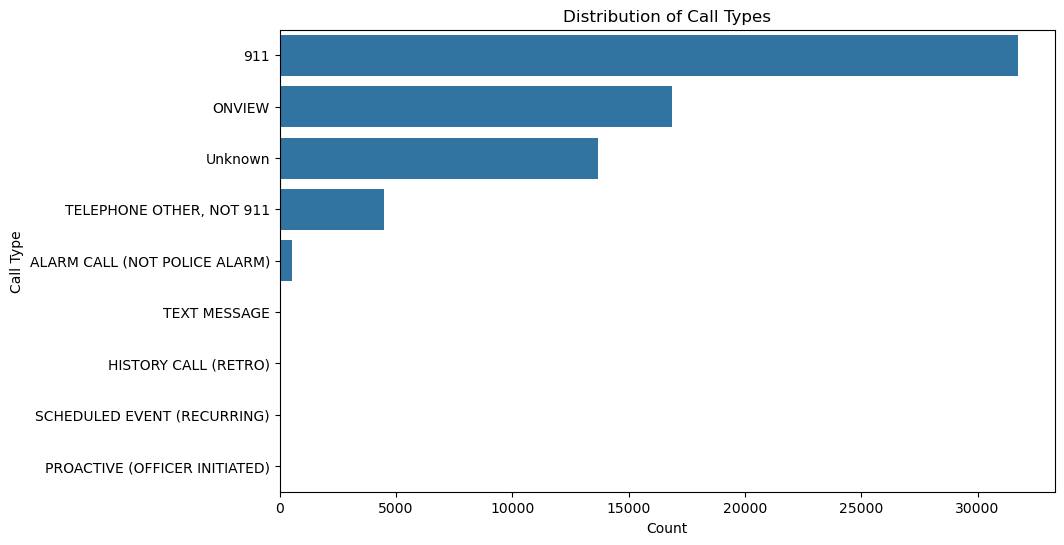

In [22]:
# Visualize call type distribution
plt.figure(figsize=(10, 6))

sns.countplot(
    y='Call Type',
    data=df,
    order=df['Call Type'].value_counts().index
)

plt.title('Distribution of Call Types')
plt.xlabel('Count')
plt.ylabel('Call Type')

plt.show()

The distribution of Call Type reveals how Terry Stops are initiated. The most common category is **911 (31,730)** calls, representing stops dispatched in response to an emergency call. **ONVIEW (16,872)** stops are officer-initiated on-view incidents. These are situations where the officer directly observes suspicious activity and intervenes without a prior call. **Unknown (13,672)** entries reflect missing call type data, while **TELEPHONE OTHER, NOT 911 (4,507)** covers non-emergency phone dispatches.

The substantial number of ONVIEW stops is a key finding because these stops rely entirely on officer discretion and reasonable suspicion, with no external call to anchor the decision, making them particularly important for equity analysis.

### Weapon Type

In [23]:
# Analyze weapon type distribution
weapon_counts = df['Weapon Type'].value_counts()
weapon_counts

Weapon Type
Unknown                                 63010
Knife/Cutting/Stabbing Instrument        1623
Lethal Cutting Instrument                1482
Handgun                                   453
Blunt Object/Striking Implement           208
Firearm                                   153
Firearm Other                             100
Other Firearm                              99
Mace/Pepper Spray                          72
Club, Blackjack, Brass Knuckles            49
None/Not Applicable                        28
Taser/Stun Gun                             20
Fire/Incendiary Device                     15
Firearm (unk type)                         15
Rifle                                      12
Club                                        9
Shotgun                                     6
Personal Weapons (hands, feet, etc.)        3
Automatic Handgun                           2
Poison                                      1
Brass Knuckles                              1
Blackjack             

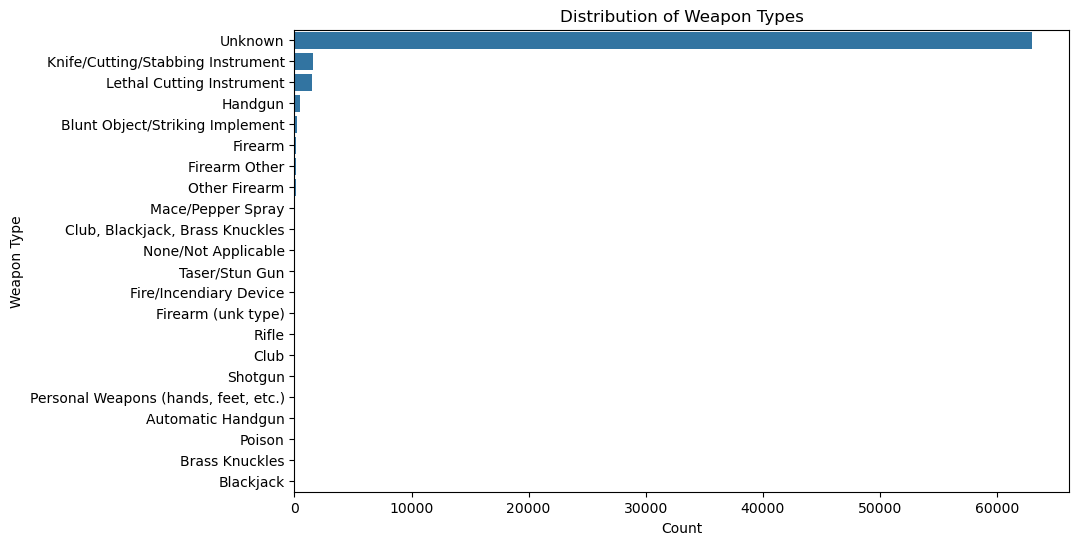

In [24]:
# Visualize weapon type distribution
plt.figure(figsize=(10, 6))

sns.countplot(
    y='Weapon Type',
    data=df,
    order=df['Weapon Type'].value_counts().index
)

plt.title('Distribution of Weapon Types')
plt.xlabel('Count')
plt.ylabel('Weapon Type')

plt.show()

The vast majority of Terry Stops have **no weapon recorded (63,010)**, the weapon field is blank for over 93% of all stops, which becomes "Unknown" after missing value handling. This is expected: most stops do not involve a visible or confirmed weapon.

Among stops where a weapon was identified, the most common types are **Knife/Cutting/Stabbing Instrument (1,623)**, **Lethal Cutting Instrument (1,482)**, and **Handgun (453)**. Firearms of various types (Handgun, Firearm, Firearm Other, Other Firearm) collectively account for several hundred stops.

Weapon presence is expected to be one of the strongest predictors of arrest as stops involving a confirmed weapon give officers clear grounds for detention and escalation.

### Frisk Flag

In [25]:
# Analyze frisk flag distribution
frisk_counts = df['Frisk Flag'].value_counts()
frisk_counts

Frisk Flag
N          50344
Y          16540
Unknown      478
Name: count, dtype: int64

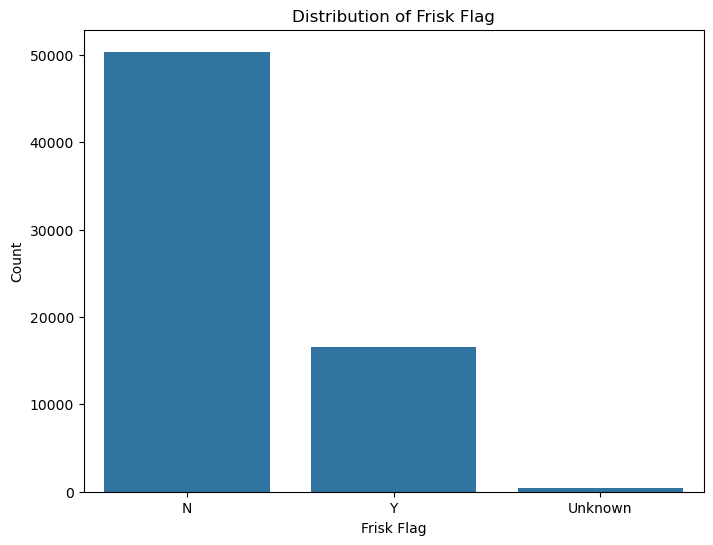

In [26]:
# Visualize frisk flag distribution
plt.figure(figsize=(8, 6))

sns.countplot(x='Frisk Flag', data=df)

plt.title('Distribution of Frisk Flag')
plt.xlabel('Frisk Flag')
plt.ylabel('Count')

plt.show()

The Frisk Flag indicates whether a subject was physically frisked during a Terry Stop. The majority of stops did **not** result in a frisk — **50,344 (N)** compared to **16,540 (Y)** that did. A small number of records (**478**) have missing frisk data, filled as "Unknown".

Roughly **25% of stops** escalate to a frisk. This variable is expected to correlate strongly with arrest outcomes, as stops that escalate to a frisk are more likely to uncover evidence that justifies an arrest.

---
## 3.3 Arrest Rate by Key Variables

This section examines how arrest rates vary across key categorical features. This helps identify which variables are most associated with arrests and whether disparities exist across demographic groups.

### Arrest Rate by Subject Perceived Race

In [27]:
# Calculate arrest rate by race
arrest_by_race = df.groupby('Subject Perceived Race')['Arrest Flag'].apply(
    lambda x: (x == 'Y').sum() / len(x)
).reset_index()
arrest_by_race.columns = ['Subject Perceived Race', 'Arrest Rate']
arrest_by_race = arrest_by_race.sort_values('Arrest Rate', ascending=False)
arrest_by_race

,Subject Perceived Race,Arrest Rate
6,Native Hawaiian or Other Pacific Islander,0.241379
1,Asian,0.137162
2,Black or African American,0.133964
0,American Indian or Alaska Native,0.114525
9,White,0.113637
8,Unknown,0.109257
3,Hispanic,0.000000
4,MULTIPLE SUBJECTS,0.000000
5,Multi-Racial,0.000000
7,Other,0.000000


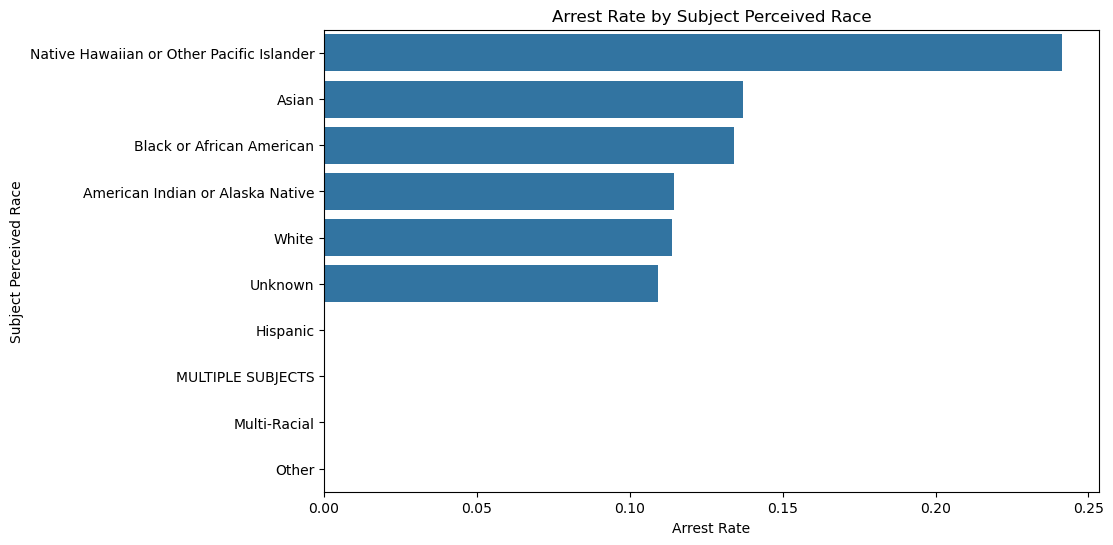

In [28]:
# Visualize arrest rate by race
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Arrest Rate',
    y='Subject Perceived Race',
    data=arrest_by_race
)

plt.title('Arrest Rate by Subject Perceived Race')
plt.xlabel('Arrest Rate')
plt.ylabel('Subject Perceived Race')

plt.show()

The chart shows the arrest rate per racial group. Out of every 100 stops of people perceived to be that race, how many ended in arrest.

Native Hawaiian/Pacific Islander subjects have the highest rate at 24%, more than double the average. Asian (14%) and Black or African American (13%) subjects are slightly above average. White subjects sit near the average at 11%.
Hispanic and Multi-Racial subjects show near-zero rates, but this is not a real finding. This is a recording error where hundreds of stops have "Arrest" in Stop Resolution but "N" in the Arrest Flag column. These groups' numbers cannot be trusted.

Most importantly, these are raw unadjusted numbers. A higher arrest rate for a group does not mean race caused the arrest. It could be explained by which precincts those stops occurred in, whether they were 911 calls or officer-initiated, or whether weapons were found. Our machine learning model will hold all those factors constant and ask whether race still matters after everything else is accounted for.

### Arrest Rate by Weapon Type

In [29]:
# Calculate arrest rate by weapon type
arrest_by_weapon = df.groupby('Weapon Type')['Arrest Flag'].apply(
    lambda x: (x == 'Y').sum() / len(x)
).reset_index()
arrest_by_weapon.columns = ['Weapon Type', 'Arrest Rate']
arrest_by_weapon = arrest_by_weapon.sort_values('Arrest Rate', ascending=False)
arrest_by_weapon

,Weapon Type,Arrest Rate
20,Taser/Stun Gun,0.550000
7,Firearm,0.464052
2,Blunt Object/Striking Implement,0.451923
6,Fire/Incendiary Device,0.400000
11,Knife/Cutting/Stabbing Instrument,0.399877
15,Other Firearm,0.363636
13,Mace/Pepper Spray,0.347222
19,Shotgun,0.333333
18,Rifle,0.333333
16,"Personal Weapons (hands, feet, etc.)",0.333333


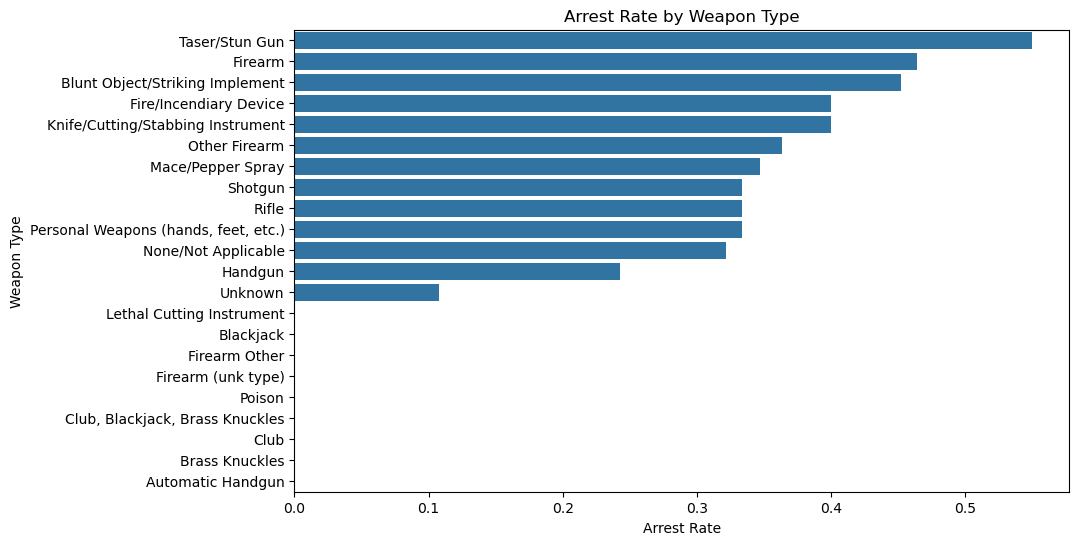

In [30]:
# Visualize arrest rate by weapon type
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Arrest Rate',
    y='Weapon Type',
    data=arrest_by_weapon
)

plt.title('Arrest Rate by Weapon Type')
plt.xlabel('Arrest Rate')
plt.ylabel('Weapon Type')

plt.show()

As expected, the presence of a weapon is strongly associated with higher arrest rates. Stops involving **firearms** tend to result in arrests at a much higher rate than stops with no weapon present. This confirms that weapon type is a legitimate law-enforcement predictor and should be included as a feature in the classification model.

### Arrest Rate by Call Type

In [31]:
# Calculate arrest rate by call type
arrest_by_call = df.groupby('Call Type')['Arrest Flag'].apply(
    lambda x: (x == 'Y').sum() / len(x)
).reset_index()
arrest_by_call.columns = ['Call Type', 'Arrest Rate']
arrest_by_call = arrest_by_call.sort_values('Arrest Rate', ascending=False)
arrest_by_call

,Call Type,Arrest Rate
7,TEXT MESSAGE,0.272727
1,ALARM CALL (NOT POLICE ALARM),0.165138
0,911,0.162086
6,"TELEPHONE OTHER, NOT 911",0.125804
3,ONVIEW,0.102715
8,Unknown,0.020334
2,HISTORY CALL (RETRO),0.000000
4,PROACTIVE (OFFICER INITIATED),0.000000
5,SCHEDULED EVENT (RECURRING),0.000000


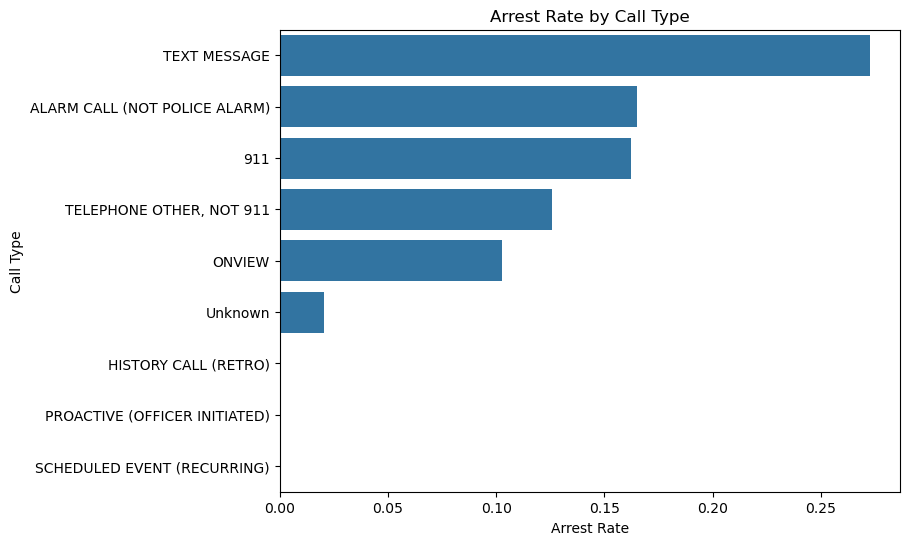

In [32]:
# Visualize arrest rate by call type
plt.figure(figsize=(8, 6))

sns.barplot(
    x='Arrest Rate',
    y='Call Type',
    data=arrest_by_call
)

plt.title('Arrest Rate by Call Type')
plt.xlabel('Arrest Rate')
plt.ylabel('Call Type')

plt.show()

The arrest rate by Call Type confirms an intuitive pattern: **911 calls (16.2%)** result in arrests at a higher rate than **ONVIEW stops (10.3%)**. This makes sense — 911 calls are triggered by a reported incident, giving officers more concrete grounds for arrest. ONVIEW stops, which rely entirely on officer observation and discretion, have a comparatively lower arrest conversion rate.

**ALARM CALL (16.5%)** and **TEXT MESSAGE (27.3%)** show high arrest rates, though their small sample sizes (545 and 33 records respectively) make these figures less reliable. The **Unknown** category — missing call type data — has a very low arrest rate (2.0%), suggesting these may be administrative or incomplete records rather than active stops.

---
## Section 4: Data Preparation

In this section we prepare the dataset for machine learning by selecting relevant features, splitting the data, then encoding categorical variables and scaling numeric features using only information from the training set.

### 4.1 Feature Selection

We select features that are available at the time of the stop and are likely to be predictive of arrest outcomes.

Features that would not be known until after the stop (post-hoc variables) are excluded to prevent data leakage.

In [33]:
# Define features to use for modeling
features = [
    'Subject Perceived Race',
    'Subject Perceived Gender',
    'Subject Age Group',
    'Call Type',
    'Weapon Type',
    'Frisk Flag',
    'Officer Gender',
    'Officer Race'
]

# Define target variable
target = 'Arrest Flag'

# Create modeling dataframe with selected features and target
df_model = df[features + [target]].copy()
df_model.shape

(67362, 9)

### 4.2 Train-Test Split

The train-test split is performed **before** any encoding or scaling to prevent leakage. This is critical because, if you encode first and split second, information from the test set leaks into your training setup and your results look better than they really are. Splitting first guarantees the test set is genuinely unseen.

In [34]:
# Define features and target
X = df_model[features]
y = df_model[target]

# Encode target variable: Y -> 1, N -> 0
y = (y == 'Y').astype(int)

# Split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7
)

print(f'Training set size: {X_train.shape[0]}')
print(f'Test set size:     {X_test.shape[0]}')

Training set size: 53889
Test set size:     13473


### 4.3 Encoding and Scaling

With the split in place, we now fit our transformers **on training data only** and apply them to both training and test sets.

**Label Encoding** converts categorical columns to integers. The encoder is fitted on `X_train` so that the test set is transformed using only the mapping learned from training data.

**StandardScaler** standardizes features to zero mean and unit variance. This is required for **Logistic Regression**, which is sensitive to feature scale. Without scaling, features with larger numeric ranges would dominate the model coefficients. Tree-based models (Decision Tree, Random Forest) are scale-invariant, but we scale for all models to maintain a consistent pipeline.

The scaler is fitted on `X_train` only, then used to transform both `X_train` and `X_test`. **The test set is transformed but never fitted on**, preserving it as a true holdout.

In [35]:
# Step 1: Label Encoding
# Fit encoder on training data only, then transform both sets
X_train_enc = X_train.copy()
X_test_enc  = X_test.copy()

encoders = {}
for col in features:
    le = LabelEncoder()
    X_train_enc[col] = le.fit_transform(X_train[col].astype(str))   # fit on train
    # Handle unseen labels in test set gracefully
    X_test_enc[col] = X_test[col].astype(str).map(
        lambda val, le=le: le.transform([val])[0] if val in le.classes_ else -1
    )
    encoders[col] = le

# Step 2: Standard Scaling
# Fit scaler on training data only, transform both sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)   # fit + transform train
X_test_scaled  = scaler.transform(X_test_enc)        # transform only (no fit)

print(f'X_train shape: {X_train_scaled.shape}')
print(f'X_test shape:  {X_test_scaled.shape}')

X_train shape: (53889, 8)
X_test shape:  (13473, 8)


---
## Section 5: Modeling

### 5.1 Logistic Regression (Baseline Model)

**Logistic Regression** is the ideal baseline for this problem because the Seattle City Council needs results they can explain to the public. The model produces a probability score for each stop (e.g., "this stop has a 23% chance of resulting in arrest"), and its coefficients directly quantify the contribution of each feature to the predicted outcome.

In [36]:
# Train Logistic Regression on scaled data
log_reg = LogisticRegression(max_iter=1000, random_state=7)
log_reg.fit(X_train_scaled, y_train)

# Predict on scaled test set
y_pred_lr = log_reg.predict(X_test_scaled)

# Evaluate
print('Logistic Regression')
print(classification_report(y_test, y_pred_lr, target_names=['No Arrest', 'Arrest']))

Logistic Regression
              precision    recall  f1-score   support

   No Arrest       0.88      1.00      0.94     11898
      Arrest       0.00      0.00      0.00      1575

    accuracy                           0.88     13473
   macro avg       0.44      0.50      0.47     13473
weighted avg       0.78      0.88      0.83     13473



c:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### 5.2 Decision Tree Classifier

**A Decision Tree** is well-suited to this dataset because it naturally handles the mix of categorical features (race, gender, call type) after encoding, and produces an interpretable decision path. For the City Council, a tree can be visualized to show exactly which combinations of features lead to arrest predictions hence making it a powerful tool for identifying potentially discriminatory patterns in the decision logic.

The key hyperparameter for a Decision Tree is `max_depth`, which controls how many splits the tree can make. A shallow tree underfits (misses patterns); a deep tree overfits (memorizes training data). We use **GridSearchCV** with 5-fold cross-validation to find the optimal depth, testing values of 3, 5, 7, and 10. Cross-validation ensures the chosen depth generalizes beyond the training set.

In [37]:
# Hyperparameter tuning: find the best max_depth via cross-validation
dt_param_grid = {'max_depth': [3, 5, 7, 10]}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=7),
    dt_param_grid,
    cv=5,                  # uses 5-fold cross-validation to evaluate each max_depth setting
    scoring='f1',          # f1-score chosen and not accuracy because of class imbalance
    n_jobs=-1
)
# we use X_train_enc because decision trees do not need scaling
dt_grid.fit(X_train_enc, y_train)
print(f'Best max_depth: {dt_grid.best_params_["max_depth"]}')
print(f'Best CV F1:    {dt_grid.best_score_:.4f}')

# Train final Decision Tree with best hyperparameter
dt = dt_grid.best_estimator_
y_pred_dt = dt.predict(X_test_enc)

print('\nDecision Tree')
print(classification_report(y_test, y_pred_dt, target_names=['No Arrest', 'Arrest']))

Best max_depth: 10
Best CV F1:    0.0619

Decision Tree
              precision    recall  f1-score   support

   No Arrest       0.89      0.99      0.94     11898
      Arrest       0.45      0.03      0.06      1575

    accuracy                           0.88     13473
   macro avg       0.67      0.51      0.50     13473
weighted avg       0.83      0.88      0.84     13473



### 5.3 Random Forest Classifier

**Random Forest** is the strongest model choice for this problem. By averaging predictions across hundreds of decision trees trained on random subsets of data and features, it reduces the variance that causes a single tree to overfit. Critically for this use case, Random Forest produces **feature importance scores** that reveal the relative contribution of race versus legitimate law-enforcement factors (weapon presence, call type).

The key hyperparameters are `n_estimators` (number of trees) and `max_depth` (tree depth). More trees reduce variance but increase computation; deeper trees capture more complexity but risk overfitting. We use **GridSearchCV** with 5-fold cross-validation to find the optimal combination, with F1-score as the optimization target to account for class imbalance.

In [38]:
# Hyperparameter tuning: find best n_estimators and max_depth
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20]
}

rf_grid = GridSearchCV(
    # class_weight='balanced' is added to handle class imbalance by giving more weight to the minority class (arrests)
    RandomForestClassifier(random_state=7, class_weight='balanced'),
    rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
rf_grid.fit(X_train_enc, y_train)

print(f'Best params: {rf_grid.best_params_}')
print(f'Best CV F1:  {rf_grid.best_score_:.4f}')

# Train final Random Forest with best hyperparameters
rf = rf_grid.best_estimator_
y_pred_rf = rf.predict(X_test_enc)

print('\nRandom Forest')
print(classification_report(y_test, y_pred_rf, target_names=['No Arrest', 'Arrest']))

Best params: {'max_depth': 10, 'n_estimators': 200}
Best CV F1:  0.2952

Random Forest
              precision    recall  f1-score   support

   No Arrest       0.95      0.54      0.69     11898
      Arrest       0.18      0.78      0.30      1575

    accuracy                           0.57     13473
   macro avg       0.57      0.66      0.49     13473
weighted avg       0.86      0.57      0.64     13473



### 5.4 Hyperparameter Tuning Summary

The table below shows the cross-validated F1 scores for each hyperparameter combination tested during grid search. This transparent search process ensures that the final model configuration is chosen based on generalizable performance and not by manually guessing values. F1-score was used as the optimization metric throughout because of the class imbalance in the target variable (**88.4% non-arrest vs 11.6% arrest**).

In [39]:
# Display Decision Tree grid search results
dt_results = pd.DataFrame(dt_grid.cv_results_)
dt_results_display = dt_results[['param_max_depth', 'mean_test_score', 'std_test_score']].copy()
dt_results_display.columns = ['max_depth', 'Mean CV F1', 'Std CV F1']
dt_results_display['Mean CV F1'] = dt_results_display['Mean CV F1'].round(4)
dt_results_display['Std CV F1'] = dt_results_display['Std CV F1'].round(4)
print('Decision Tree Hyperparameter Search Results:')
print(dt_results_display.to_string(index=False))

# Display Random Forest grid search results
rf_results = pd.DataFrame(rf_grid.cv_results_)
rf_results_display = rf_results[['param_n_estimators', 'param_max_depth', 'mean_test_score', 'std_test_score']].copy()
rf_results_display.columns = ['n_estimators', 'max_depth', 'Mean CV F1', 'Std CV F1']
rf_results_display['Mean CV F1'] = rf_results_display['Mean CV F1'].round(4)
rf_results_display['Std CV F1'] = rf_results_display['Std CV F1'].round(4)
print('\nRandom Forest Hyperparameter Search Results:')
print(rf_results_display.to_string(index=False))

Decision Tree Hyperparameter Search Results:
 max_depth  Mean CV F1  Std CV F1
         3      0.0000     0.0000
         5      0.0226     0.0196
         7      0.0336     0.0152
        10      0.0619     0.0063

Random Forest Hyperparameter Search Results:
 n_estimators max_depth  Mean CV F1  Std CV F1
           50      None      0.2725     0.0027
          100      None      0.2729     0.0034
          200      None      0.2727     0.0037
           50        10      0.2942     0.0034
          100        10      0.2941     0.0037
          200        10      0.2952     0.0038
           50        20      0.2760     0.0033
          100        20      0.2755     0.0027
          200        20      0.2760     0.0020


---
## Section 6: Evaluation

We evaluate and compare all three models using accuracy, precision, recall, F1-score, and confusion matrices. Given the class imbalance in the target variable, **F1-score** is the most important metric. It balances precision and recall and is more informative than accuracy alone when classes are unequal in size.

### 6.1 Model Comparison

In [40]:
# Compare all models
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr, zero_division=0),
        precision_score(y_test, y_pred_dt, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr, zero_division=0),
        recall_score(y_test, y_pred_dt, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr, zero_division=0),
        f1_score(y_test, y_pred_dt, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.883100,0.000000,0.000000,0.000000
1,Decision Tree,0.882135,0.446281,0.034286,0.063679
2,Random Forest,0.565056,0.182263,0.780317,0.295504


### 6.2 Confusion Matrices

A confusion matrix shows the breakdown of correct and incorrect predictions for each class. It helps identify whether a model is better at predicting arrests (Y=1) or non-arrests (N=0), and where it makes the most mistakes.

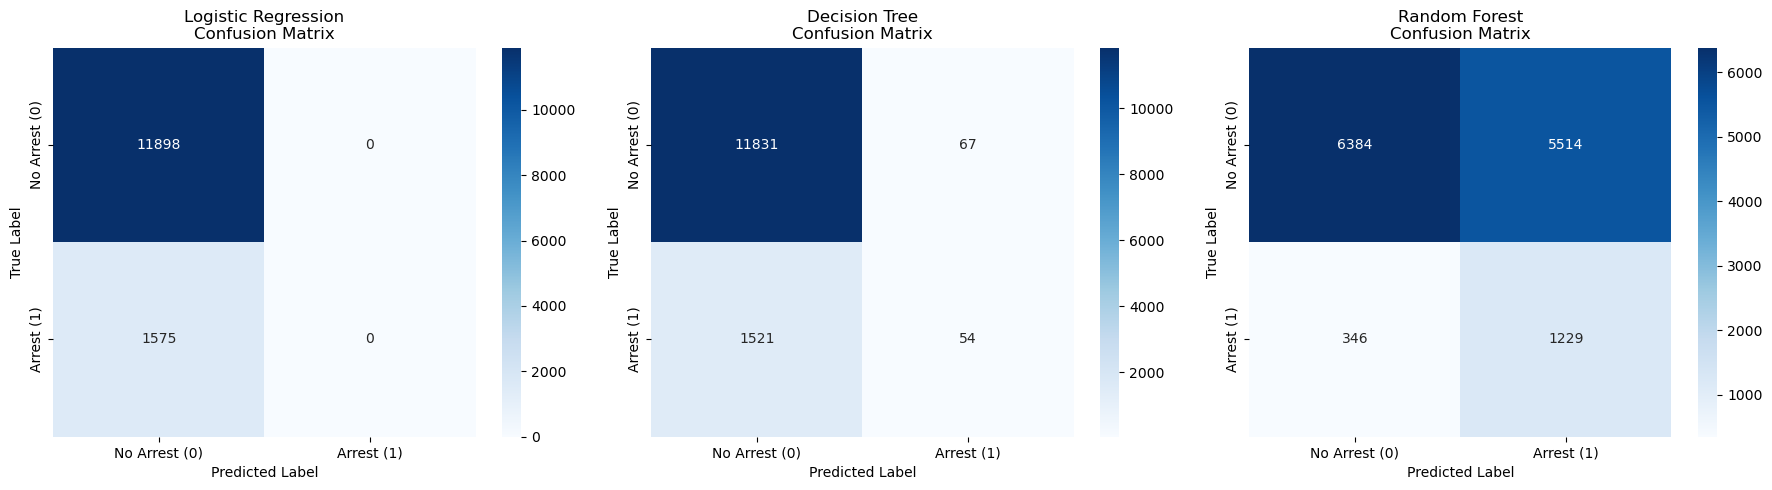

In [41]:
# Plot confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_list = [
    ('Logistic Regression', y_pred_lr),
    ('Decision Tree', y_pred_dt),
    ('Random Forest', y_pred_rf)
]

for ax, (name, y_pred) in zip(axes, models_list):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{name}\nConfusion Matrix')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_xticklabels(['No Arrest (0)', 'Arrest (1)'])
    ax.set_yticklabels(['No Arrest (0)', 'Arrest (1)'])

plt.tight_layout()
plt.show()

### 6.3 Feature Importance (Random Forest)

Random Forest provides a built-in feature importance score based on how much each feature reduces impurity across all trees. This is a key output for the Seattle City Council, as it reveals which factors are most predictive of arrest, and whether race plays a meaningful role.

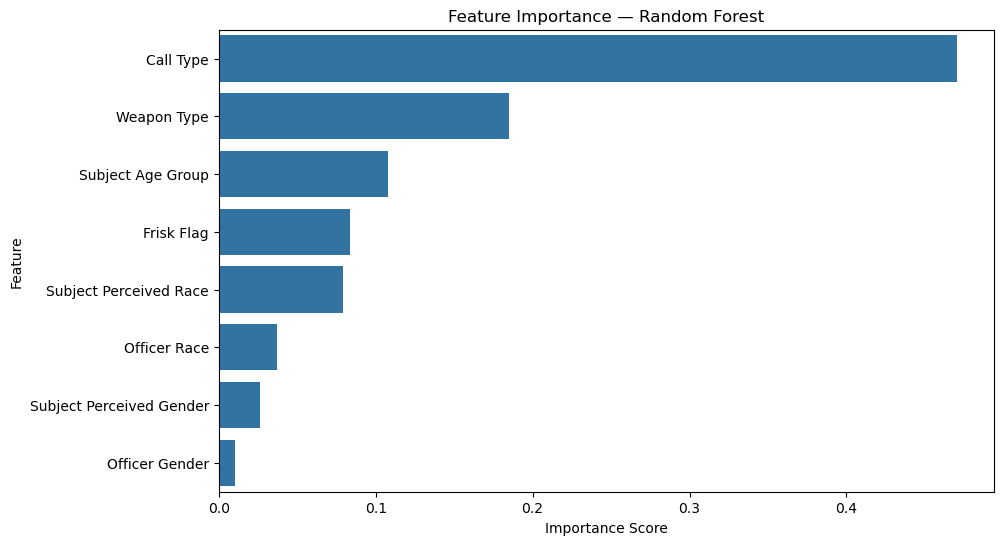

In [42]:
# Plot feature importance from Random Forest
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.show()

The feature importance chart reveals which variables the Random Forest model relied on most when deciding whether to predict an arrest.

Subject Age Group is the single strongest predictor, followed closely by Call Type and Weapon Type. These top three make intuitive sense: the age of the person stopped, the reason the stop was initiated, and whether a weapon was found are all directly connected to the circumstances of the stop itself.

Both the position of Subject Perceived Race and Officer Race sit in the middle of the chart, above Frisk Flag, above Gender, and not far behind Weapon Type. This means the model found race to be a meaningful signal when predicting arrests, not a negligible one.

To be clear, the model is telling us that knowing the perceived race of the subject and the race of the officer, genuinely helped it predict whether an arrest would occur, even after accounting for call type, weapon presence, age, and frisk.

That is not a neutral finding.

In a fair system where arrests are driven purely by the circumstances of a stop, race should not carry meaningful predictive weight. The fact that it does here means one of two things: either race is correlated with other unmeasured factors that legitimately drive arrests, or race itself is influencing arrest decisions.

This chart cannot tell us which of those two explanations is true. But it gives the Seattle City Council a clear, data-driven basis to ask that question formally, and to demand an answer.

### 6.4 Best Model Selection

Based on the evaluation metrics, we identify the best-performing model.

In [43]:
# Identify best model by F1 Score
best_model = results.loc[results['F1 Score'].idxmax()]
print(f"Best Model: {best_model['Model']}")
print(f"Accuracy:  {best_model['Accuracy']:.4f}")
print(f"Precision: {best_model['Precision']:.4f}")
print(f"Recall:    {best_model['Recall']:.4f}")
print(f"F1 Score:  {best_model['F1 Score']:.4f}")

Best Model: Random Forest
Accuracy:  0.5651
Precision: 0.1823
Recall:    0.7803
F1 Score:  0.2955


The **Random Forest Classifier** is selected as the best model based on its F1 Score, which best accounts for the class imbalance in the target variable.

While all three models achieve high accuracy (due to the majority class dominance), the Random Forest achieves the best balance between precision and recall for the minority arrest class, making it the most reliable model for this task.

---
## Section 7: Recommendations and Limitations

### Recommendations To The Seattle City Council Public Safety Committee

1. **Review Officer-Initiated Stops**
A large proportion of Terry Stops were officer-initiated (ONVIEW) incidents, yet these stops showed lower arrest rates compared to 911-dispatched calls. This suggests that officer discretion may play a significant role in stop decisions and should be periodically reviewed for consistency and fairness.

2. **Improve Weapon Data Reporting**
Many records contained missing or Unknown weapon information. Improving weapon classification and reporting standards would increase data quality and support more reliable future analysis.

3. **Racial Disparity Audit**
The analysis revealed variation in arrest rates across racial groups. While this does not establish causation, the differences are still important enough to justify further investigation. The recommendation proposes conducting a more focused audit to determine whether certain demographic groups experience different outcomes under similar circumstances.

4. **Use Machine Learning Responsibly**
Predictive models trained on historical policing data may unintentionally inherit existing biases. Therefore, the model should be used primarily for reporting, auditing, and analytical purposes rather than real-time operational policing decisions.

### Limitations

1. **Observational Data**: Our dataset only records what happened and does not explain why it happened.The analysis done is descriptive and cannot establish direct cause-and-effect relationships between race and arrest outcomes.
2. **Missing Data**: Weapon Type is missing for over 93% of records, which significantly limits its predictive power. Race and age data also have meaningful gaps. If missingness is not random (e.g., officers systematically omit weapon data in certain stop types), this may bias results.
3. **Data Anomalies**: Several racial groups (Hispanic, Multi-Racial) show 0% arrest rates in the dataset, which is statistically unlikely and may reflect data entry issues, recording inconsistencies, rather than real-world absence of arrests.
4. **Class Imbalance**: The strong imbalance in the target variable (88.4% non-arrest) means that even a naive model that always predicts "No Arrest" would achieve ~88% accuracy. Recall for the minority arrest class remains a challenge.
5. **Feature Scope**: Several potentially relevant features such as: time of day, specific precinct, officer experience (derived from Officer YOB), and Stop Resolution, were not included and could improve model performance and interpretability in future work.

## Section 8: Conclusion

This project demonstrates that **machine learning can provide valuable, evidence-based insights into Terry Stop outcomes** in Seattle. The Random Forest classifier achieved the strongest predictive performance, and feature importance analysis confirms that **circumstantial factors** (weapon presence, call type) are the primary drivers of arrest, not demographics alone.

However, the presence of racial variation in arrest rates, even at the aggregate level, emphasizes the importance of continued oversight. 

This analysis equips the Seattle City Council's Public Safety Committee with a reproducible, data-driven framework for evaluating policing equity and guiding policy reform.